## Imports

In [30]:
%load_ext autoreload
%autoreload 2

import logging
import os

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# import helpers.hmodule as hmodule

# hmodule.install_module_if_not_present(
#     "networkx",
#     use_activate=True,
# )
# hmodule.install_module_if_not_present(
#     "pgmpy",
#     use_activate=True,
# )

In [3]:
import helpers.hnotebook as hnotebo

import msml610_utils as ut
import L08_04_05_causal_inference_utils as mtl0cire05

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)
hnotebo.set_logger_to_print(_LOG)
hnotebo.set_all_loggers_to_print()

pymc is not installed
arviz is not installed
preliz is not installed
sns is not installed


Python 3.12.13
Linux 3f3aef6a9c0f 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 GNU/Linux


In [4]:
dir_name = "L08_data"
#!ls $dir_name

out_dir_name = "figures/"

In [5]:
df = pd.read_csv(os.path.join(dir_name, "management_training.csv"))
import helpers.hpandas_display as hpandisp

hpandisp.display_df(df)

,departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size
0,76,1,0.277359,6,4,2,4,0.614261,0.224077,843
1,76,1,-0.449646,4,8,2,4,0.069636,0.224077,843
...,...,...,...,...,...,...,...,...,...,...
10389,1,0,-0.396297,5,4,1,3,-1.277477,1.005063,323
10390,1,1,0.47897,5,1,2,3,-1.584552,1.005063,323


The dataset contains information on managers with the following variables:

- **intervention**: Binary treatment indicator (1 = received training, 0 =
  control)
- **engagement_score**: Primary outcome—average standardized engagement score of
  manager's employees
- **department_id**: Unique department identifier
- **tenure**: Years the manager has been with the company
- **n_of_reports**: Number of direct reports the manager has
- **gender**: Manager's identified gender (categorical)
- **role**: Job category within the company (categorical)
- **department_size**: Number of employees in the department
- **department_score**: Average engagement score in the department
- **last_engagement_score**: Previous period's engagement score for the manager

INFO:helpers.hpandas_stats:stats_df=


,num_rows,zeros [%],nans [%],infs [%],valid [%],num_unique,unique [%]
departament_id,10391,0.0,0.0,0.0,100.0,76,0.73
intervention,10391,46.0,0.0,0.0,54.0,2,0.02
engagement_score,10391,0.0,0.0,0.0,100.0,10391,100.0
tenure,10391,0.0,0.0,0.0,100.0,7,0.07
n_of_reports,10391,0.0,0.0,0.0,100.0,8,0.08
gender,10391,0.0,0.0,0.0,100.0,2,0.02
role,10391,8.13,0.0,0.0,91.87,5,0.05
last_engagement_score,10391,0.0,0.0,0.0,100.0,10391,100.0
department_score,10391,0.0,0.0,0.0,100.0,76,0.73
department_size,10391,0.0,0.0,0.0,100.0,72,0.69


INFO:helpers.hpandas_stats:Univariate distributions:


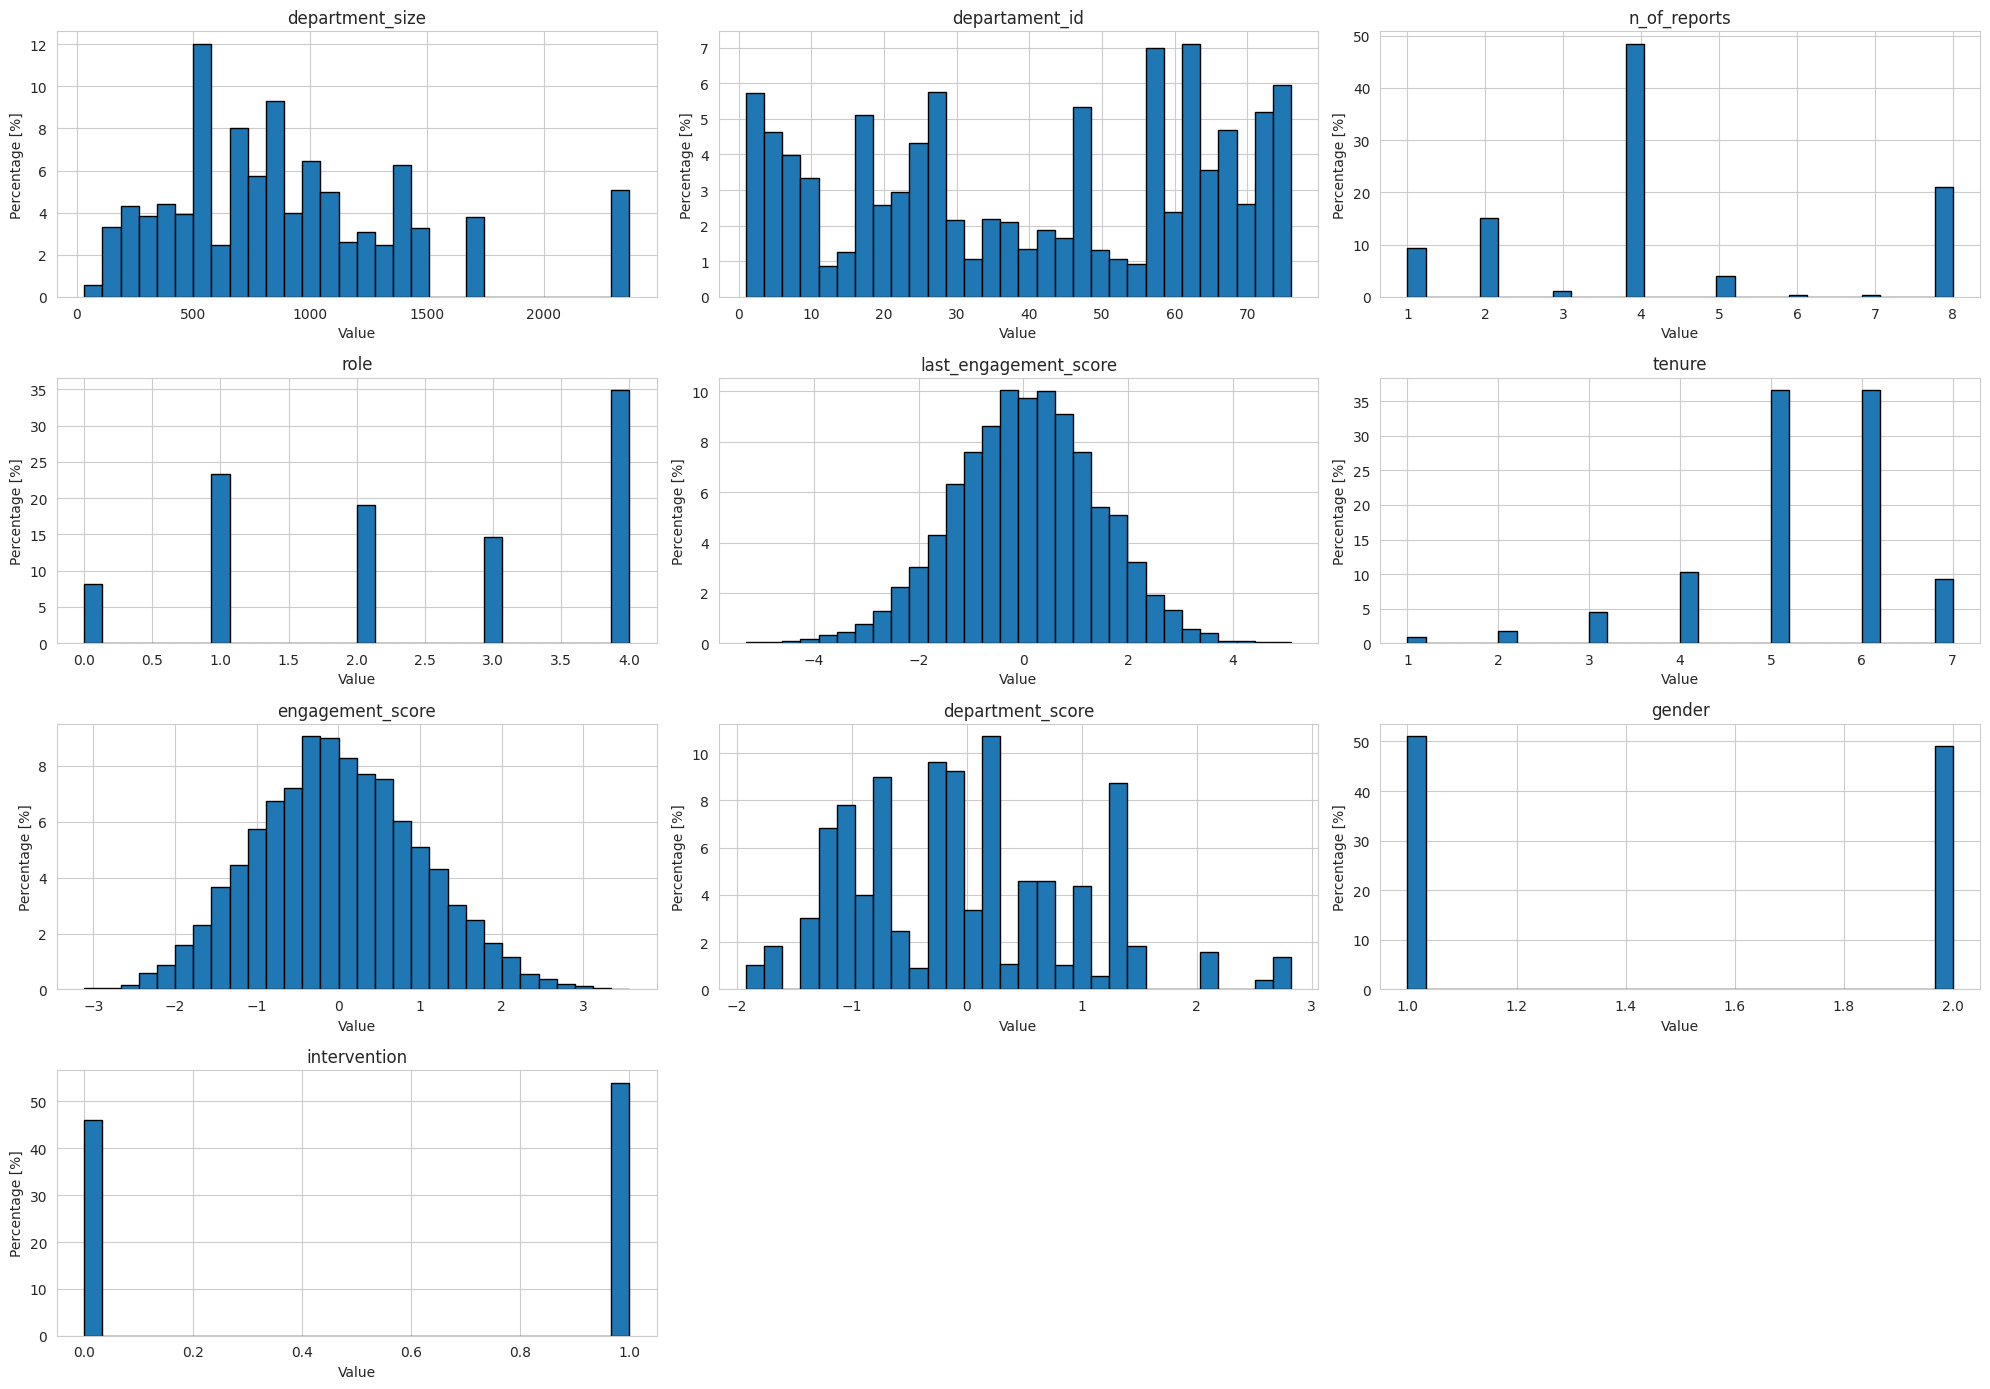

INFO:helpers.hpandas_stats:Correlation matrix:


,departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size
departament_id,1.000000,0.002266,-0.078337,0.029178,0.053808,0.006494,0.141227,0.027869,0.121768,0.259454
intervention,0.002266,1.000000,0.216614,0.199276,0.000497,-0.031315,-0.026555,0.104083,-0.065904,0.063432
engagement_score,-0.078337,0.216614,1.000000,0.438577,-0.008746,-0.159343,0.051367,0.011241,0.013696,0.006148
tenure,0.029178,0.199276,0.438577,1.000000,-0.009208,-0.043800,-0.029627,0.053055,-0.052548,0.036704
n_of_reports,0.053808,0.000497,-0.008746,-0.009208,1.000000,-0.008218,-0.024649,0.030823,-0.053213,0.027211
gender,0.006494,-0.031315,-0.159343,-0.043800,-0.008218,1.000000,0.008840,0.000496,0.005535,0.004224
role,0.141227,-0.026555,0.051367,-0.029627,-0.024649,0.008840,1.000000,-0.123305,0.401507,0.159458
last_engagement_score,0.027869,0.104083,0.011241,0.053055,0.030823,0.000496,-0.123305,1.000000,-0.281688,0.275172
department_score,0.121768,-0.065904,0.013696,-0.052548,-0.053213,0.005535,0.401507,-0.281688,1.000000,-0.088321
department_size,0.259454,0.063432,0.006148,0.036704,0.027211,0.004224,0.159458,0.275172,-0.088321,1.000000


In [6]:
import helpers.hpandas_stats as hpanstat

show_distributions = True
show_correlations = True

hpanstat.explore_dataframe(
    df,
    show_distributions=show_distributions,
    show_correlations=show_correlations,
)

In [7]:
import statsmodels.formula.api as smf

In [8]:
model = smf.ols("engagement_score ~ intervention", data=df).fit()
print("ATE:", model.params["intervention"])
print("95% CI:", model.conf_int().loc["intervention", :].values.T)

smf.ols("engagement_score ~ intervention", data=df).fit().summary().tables[1]

ATE: 0.43459886274141496
95% CI: [0.39693035 0.47226738]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.2347,0.014,-16.619,0.000,-0.262,-0.207
intervention,0.4346,0.019,22.616,0.000,0.397,0.472


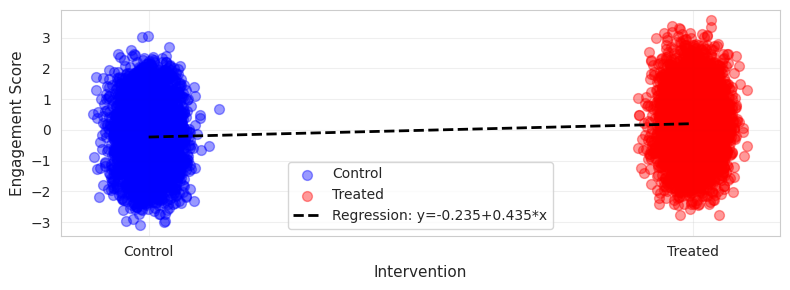

In [9]:
mtl0cire05.plot_engagement_vs_intervention(df)

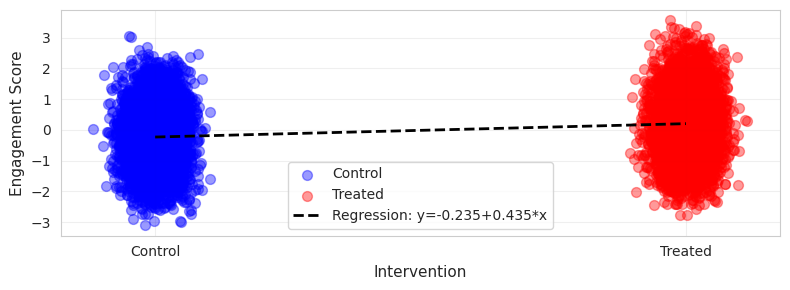

In [10]:
# Density curves comparing distributions
mtl0cire05.plot_engagement_vs_intervention(df)

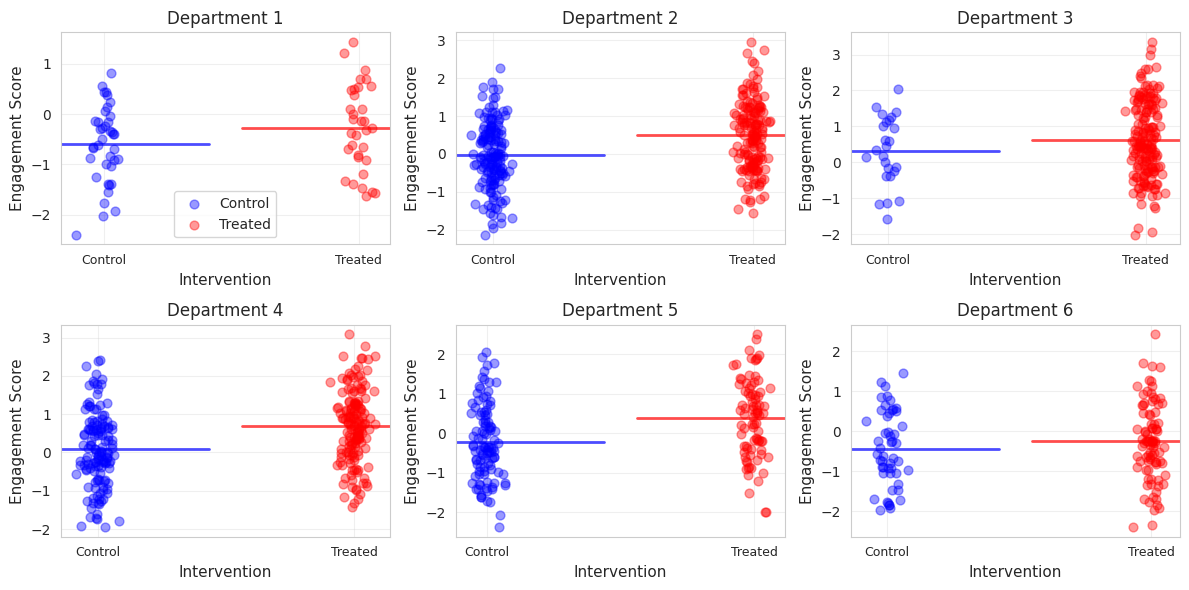

In [11]:
mtl0cire05.plot_engagement_vs_intervention_by_department(df)

In [12]:
# mtl0cire05.plot_all_variables_vs_intervention(df)

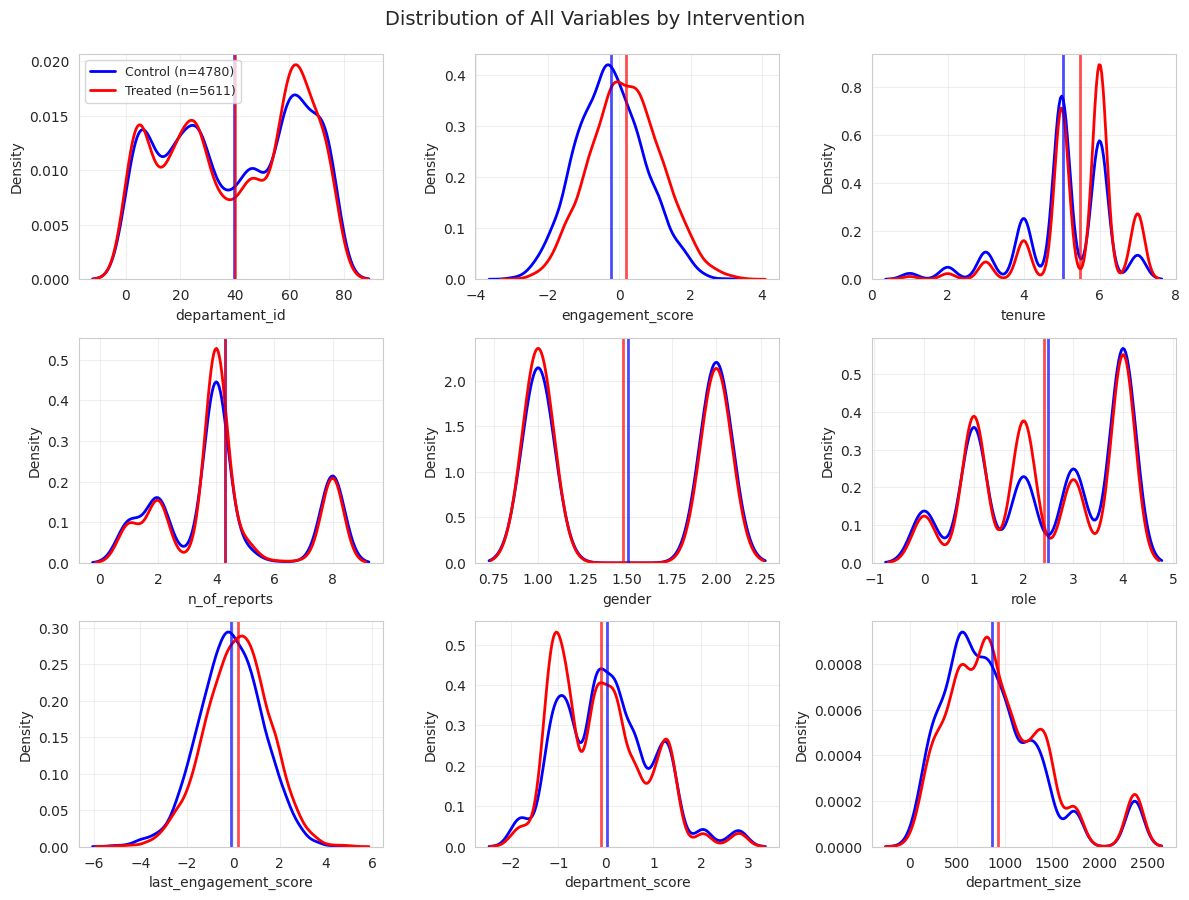

In [13]:
mtl0cire05.plot_all_variables_density_by_intervention(df)

In [14]:
# To reduce this bias, you can adjust for the covariates you have in your data.
model = smf.ols(
    """
    engagement_score ~ intervention
        + tenure + last_engagement_score + department_score
        + n_of_reports + C(gender) + C(role)""",
    data=df,
).fit()

print("ATE:", model.params["intervention"])
print("95% CI:", model.conf_int().loc["intervention", :].values.T)

ATE: 0.26779085766768607
95% CI: [0.23357751 0.30200421]


In [15]:
model = smf.ols("engagement_score ~ intervention", data=df).fit()
print("ATE:", model.params["intervention"])
print("95% CI:", model.conf_int().loc["intervention", :].values.T)

ATE: 0.43459886274141496
95% CI: [0.39693035 0.47226738]


- The effect estimate here is considerably smaller than the one you got earlier.
- This is some indication of positive bias, which means that managers whose
  employees were already more engaged are more likely to have participated in the
  manager training program

## Propensity score

In [16]:
ps_model = smf.logit(
    """
    intervention ~
        tenure + last_engagement_score + department_score
        + C(n_of_reports) + C(gender) + C(role)""",
    data=df,
).fit(disp=0)

data_ps = df.copy()
data_ps["propensity_score"] = ps_model.predict(df)

data_ps[["intervention", "engagement_score", "propensity_score"]].head()

,intervention,engagement_score,propensity_score
0,1,0.277359,0.596106
1,1,-0.449646,0.391138
2,1,0.769703,0.602578
3,1,-0.121763,0.580990
4,1,1.526147,0.619976


In [17]:
# Estimate using propensity score as confounder / covariate.
model = smf.ols(
    """
    engagement_score ~ intervention + propensity_score
    """,
    data=data_ps,
).fit()
print(model.params["intervention"])

0.26331267490277155


## Propensity score matching

In [18]:
# Perform 1-nearest neighbor propensity score matching.
predicted = mtl0cire05.propensity_score_matching(data_ps)
predicted.head()

,departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size,propensity_score,match
0,76,1,0.277359,6,4,2,4,0.614261,0.224077,843,0.596106,0.557680
1,76,1,-0.449646,4,8,2,4,0.069636,0.224077,843,0.391138,-0.952622
2,76,1,0.769703,6,4,2,4,0.866918,0.224077,843,0.602578,-0.618381
3,76,1,-0.121763,6,4,2,4,0.029071,0.224077,843,0.580990,-1.404962
4,76,1,1.526147,6,4,1,4,0.589857,0.224077,843,0.619976,0.000354


In [19]:
# Calculate average treatment effect from propensity score matching.
hat_ATE = mtl0cire05.calculate_psm_ate(predicted)
print(f"ATE (Propensity Score Matching): {hat_ATE:.4f}")

ATE (Propensity Score Matching): 0.2878


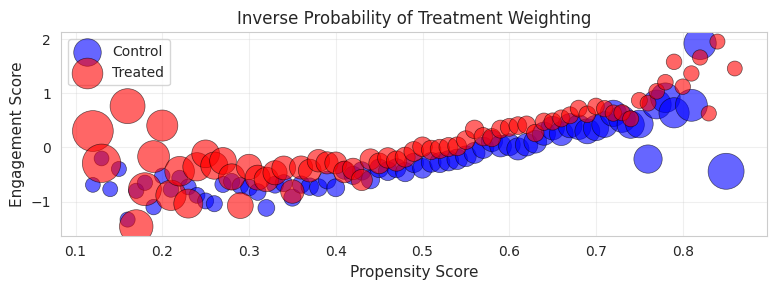

In [20]:
# Plot inverse probability of treatment weighting results.
mtl0cire05.plot_iptw(data_ps)

In [ ]:
# Estimate ATE using IPTW.
weighted_e_y1, weighted_e_y0, hat_ATE = mtl0cire05.estimate_ate_iptw(data_ps)

print("E[Y1]:", weighted_e_y1)
print("E[Y0]:", weighted_e_y0)
print("ATE:", hat_ATE)

# Variance

In [ ]:
# Prepare formula and variables for IPW estimation.
formula = """
tenure + last_engagement_score + department_score
    + C(n_of_reports) + C(gender) + C(role)
"""
T = "intervention"
Y = "engagement_score"

In [ ]:
# Estimate ATE using IPW estimator.
ate_ipw = mtl0cire05.estimate_ate_with_ps(
    df, formula, treatment_col=T, outcome_col=Y
)
print(f"ATE (IPW): {ate_ipw:.4f}")

In [ ]:
# Compute bootstrap 95% confidence interval for ATE using IPW.
print(f"ATE: {ate_ipw:.4f}")

# Define bootstrap function that resamples data and computes ATE.
est_fn = lambda data: mtl0cire05.estimate_ate_with_ps(
    data, ps_formula=formula, treatment_col=T, outcome_col=Y
)

# Estimate confidence interval using bootstrap resampling.
ci = mtl0cire05.estimate_confidence_interval_bootstrap(
    df, est_fn, rounds=200, seed=123, n_jobs=4, pcts=[2.5, 97.5]
)
print(f"95% Confidence interval: {ci}")

# Stabilized Propensity Weights

In [45]:
# Show sample sizes for original and pseudo-population.
print("Original Sample Size:", data_ps.shape[0])

# Compute sample sizes after IPTW weighting.
treated = data_ps.query("intervention==1")
control = data_ps.query("intervention==0")

weight_t = 1 / treated["propensity_score"]
weight_nt = 1 / (1 - control["propensity_score"])

print("Treated Pseudo-Population Sample Size:", sum(weight_t))
print("Untreated Pseudo-Population Sample Size:", sum(weight_nt))

Original Sample Size: 10391
Treated Pseudo-Population Sample Size: 10435.089079197925
Untreated Pseudo-Population Sample Size: 10354.298899788268


In [46]:
# Estimate ATE using stabilized propensity weights.
ate_stabilized = mtl0cire05.estimate_ate_stabilized_weights(data_ps)

print(f"ATE (Stabilized Weights): {ate_stabilized:.4f}")

ATE (Stabilized Weights): 0.2660


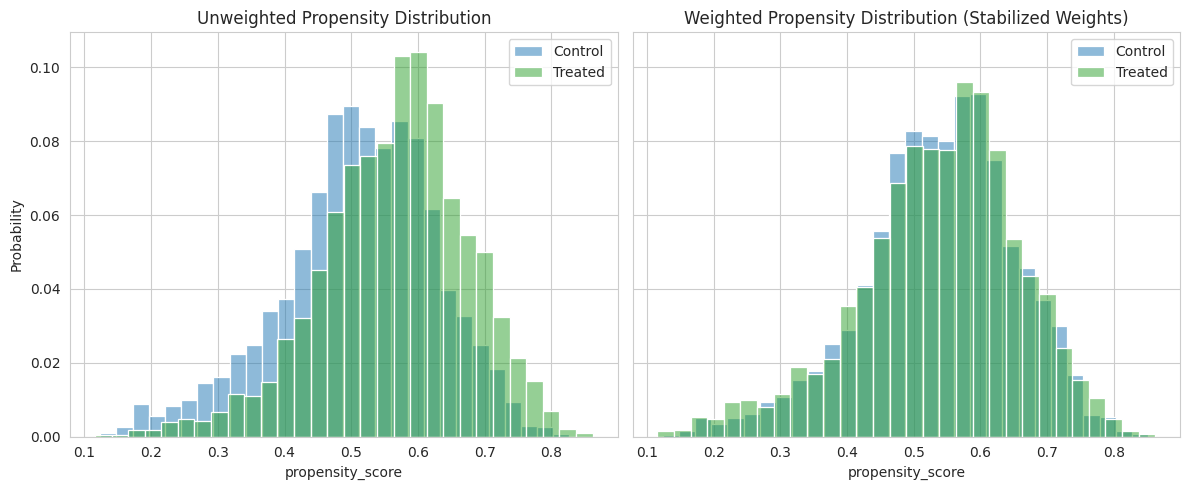

In [48]:
# Plot propensity score distributions before and after weighting.
mtl0cire05.plot_propensity_distributions(data_ps)